# Face Vector Store with FAISS

This notebook demonstrates how to build a persistent face database using the **FAISS** vector store in UniFace.

Unlike direct pairwise comparison (see `04_face_search`), a vector store lets you efficiently index
thousands of face embeddings and retrieve the closest match in sub-millisecond time.

## 1. Install UniFace

In [1]:
%pip install -q uniface faiss-cpu

# Clone repo for assets (Colab only)
import os
if 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ:
    if not os.path.exists('uniface'):
        !git clone --depth 1 https://github.com/yakhyo/uniface.git
    os.chdir('uniface/examples')

Note: you may need to restart the kernel to use updated packages.


## 2. Import Libraries

In [2]:
import cv2
import matplotlib.pyplot as plt
import shutil

import uniface
from uniface.analyzer import FaceAnalyzer
from uniface.detection import RetinaFace
from uniface.recognition import ArcFace
from uniface.stores import FAISS

print(f'UniFace version: {uniface.__version__}')

UniFace version: 3.2.0


## 3. Initialize Models and Vector Store

In [3]:
analyzer = FaceAnalyzer(
    detector=RetinaFace(confidence_threshold=0.5),
    recognizer=ArcFace(),
)

DB_PATH = './demo_face_index'
store = FAISS(embedding_size=512, db_path=DB_PATH)
print(store)

FAISS(embedding_size=512, vectors=0)


## 4. Enroll Faces into the Store

We detect faces in the test images and add each embedding with metadata.

In [4]:
enrollment_images = {
    '../assets/test_images/image0.jpg': 'person_0',
    '../assets/test_images/image1.jpg': 'person_1',
    '../assets/test_images/image2.jpg': 'person_2',
    '../assets/test_images/image3.jpg': 'person_3',
    '../assets/test_images/image4.jpg': 'person_4',
}

for path, label in enrollment_images.items():
    image = cv2.imread(path)
    faces = analyzer.analyze(image)
    if faces:
        store.add(
            embedding=faces[0].embedding,
            metadata={'label': label, 'source': path},
        )
        print(f'Enrolled {label} from {path}')

print(f'\nStore size: {store.size} vectors')

Enrolled person_0 from ../assets/test_images/image0.jpg
Enrolled person_1 from ../assets/test_images/image1.jpg
Enrolled person_2 from ../assets/test_images/image2.jpg
Enrolled person_3 from ../assets/test_images/image3.jpg
Enrolled person_4 from ../assets/test_images/image4.jpg

Store size: 5 vectors


## 5. Search the Store

Use a query image to find the closest match in the database.

In [5]:
query_image = cv2.imread('../assets/test_images/image0.jpg')
query_faces = analyzer.analyze(query_image)

if query_faces:
    result, similarity = store.search(query_faces[0].embedding, threshold=0.4)

    if result:
        print(f'Match found: {result["label"]} (similarity: {similarity:.4f})')
        print(f'Source:      {result["source"]}')
    else:
        print(f'No match above threshold (best similarity: {similarity:.4f})')

Match found: person_0 (similarity: 1.0000)
Source:      ../assets/test_images/image0.jpg


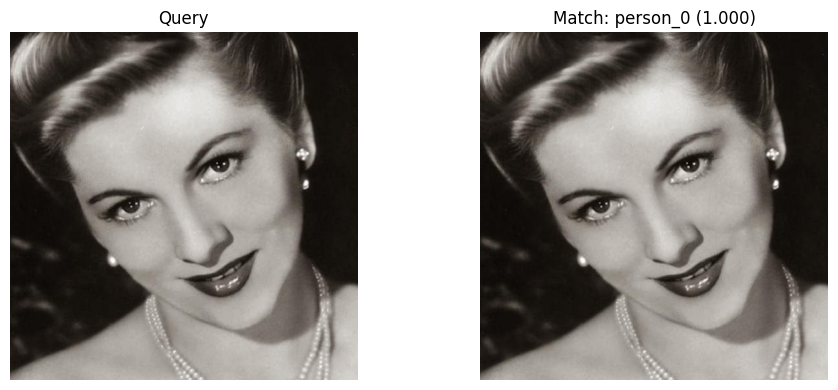

In [6]:
if query_faces and result:
    matched_image = cv2.imread(result['source'])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(cv2.cvtColor(query_image, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Query', fontsize=12)
    axes[1].imshow(cv2.cvtColor(matched_image, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Match: {result["label"]} ({similarity:.3f})', fontsize=12)
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 6. Save and Reload the Index

The index and metadata can be persisted to disk and loaded later.

In [7]:
store.save()

# Create a fresh store and load the saved data
store_reloaded = FAISS(embedding_size=512, db_path=DB_PATH)
loaded = store_reloaded.load()
print(f'Load successful: {loaded}')
print(f'Reloaded store size: {store_reloaded.size} vectors')

# Verify search still works after reload
if query_faces:
    result, similarity = store_reloaded.search(query_faces[0].embedding, threshold=0.4)
    if result:
        print(f'Search after reload: {result["label"]} ({similarity:.4f})')

Load successful: True
Reloaded store size: 5 vectors
Search after reload: person_0 (1.0000)


## 7. Remove Entries

Remove all entries matching a metadata key-value pair.

In [8]:
print(f'Before removal: {store.size} vectors')

removed = store.remove(key='label', value='person_0')
print(f'Removed {removed} entry')
print(f'After removal:  {store.size} vectors')

# Searching for the removed person should now return a different (lower) match
if query_faces:
    result, similarity = store.search(query_faces[0].embedding, threshold=0.4)
    if result:
        print(f'\nClosest remaining match: {result["label"]} ({similarity:.4f})')
    else:
        print(f'\nNo match above threshold (best similarity: {similarity:.4f})')

Before removal: 5 vectors
Removed 1 entry
After removal:  4 vectors

No match above threshold (best similarity: 0.1724)


## 8. Cleanup

In [9]:
shutil.rmtree(DB_PATH, ignore_errors=True)
print('Cleaned up demo index.')

Cleaned up demo index.


## Notes

- Embeddings **must** be L2-normalised before adding (ArcFace already produces normalised embeddings)
- The default threshold of `0.4` works for most cases; raise it for stricter matching
- `save()` / `load()` persist the FAISS index and metadata as files in `db_path`
- For GPU-accelerated search install `faiss-gpu` instead of `faiss-cpu`
- The store uses `IndexFlatIP` (inner product = cosine similarity for normalised vectors)